--- Resultados do Método da Bissecção  ---
A raiz aproximada no intervalo [-1, 1] é: -0.6035199165344238
O valor da função na raiz aproximada f(-0.603520) é: -7.599008e-07
Quantidade de iterações realizadas: 21

Investigando outros intervalos para encontrar outras raízes:

Testando o intervalo [0, 2]:
O método da bissecção pode não encontrar uma raiz neste intervalo (f(a) e f(b) têm o mesmo sinal).
Nenhuma raiz encontrada neste intervalo.

Testando o intervalo [-2, 0]:
A raiz aproximada no intervalo [-2, 0] é: -0.6035199165344238
f(-0.603520) = -7.599008e-07
Quantidade de iterações realizadas: 21

Testando o intervalo [-5, 5]:
A raiz aproximada no intervalo [-5, 5] é: -0.6035193800926208
f(-0.603519) = 6.671694e-07
Quantidade de iterações realizadas: 24

--- Resultados do Método de Newton-Raphson ---
Ponto inicial: 0
Tolerância: 1e-06
A raiz aproximada encontrada é: -0.6035196308845124
f(-0.603520) = 1.110223e-16
Número de iterações realizadas: 6


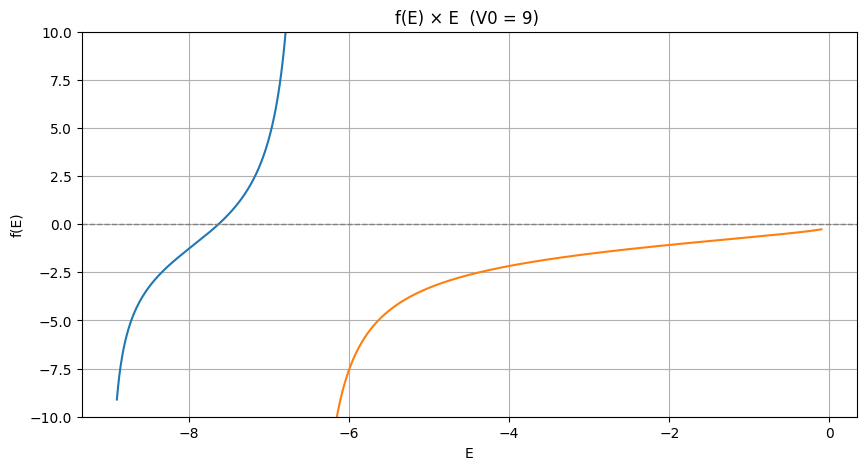


--- Resultados do Método da Secante ---
Chutes iniciais: E0 = -7.631200, E1 = -7.630051
Tolerância: 1e-06
Raiz (energia do estado fundamental): E* = -7.630817100307
f(E*) = -5.277109e-07
Número de linhas na tabela: 3

Iter |           E_k           |          f(E_k)
   0 | -7.631200192746 | -1.465820e-03
   1 | -7.630050917558 |  2.931632e-03
   2 | -7.630817100307 | -5.277109e-07


In [3]:
"""
EP1 - Zeros de Funções
Autor: Danilo Cho (NUSP 10769448)

"""

# -------------------- (a) Bissecção --------------------
import numpy as np
import matplotlib.pyplot as plt
import math

def f(x):
    return x**3 + x + np.cos(x)

def bissecção(a, b, e=1e-6, max_iterations=100):
    x1 = a
    x2 = b
    iterations_data = []
    iter_count = 0

    # Verificação de mudança de sinal no intervalo inicial
    if f(a) * f(b) >= 0:
        print("O método da bissecção pode não encontrar uma raiz neste intervalo (f(a) e f(b) têm o mesmo sinal).")
        return None, None

    # Loop principal do método da bissecção
    while abs(x2 - x1) > e and iter_count < max_iterations:
        xm = (x1 + x2) / 2
        f_x1 = f(x1)
        f_xm = f(xm)

        # Armazena os dados da iteração atual
        iterations_data.append((iter_count, x1, x2, xm, f_x1, f_xm))

        # Atualização do intervalo
        if f_x1 * f_xm < 0:
            x2 = xm
        else:
            x1 = xm

        iter_count += 1

    # Raiz aproximada como o ponto médio do intervalo final
    raiz = (x1 + x2) / 2
    return raiz, iterations_data

# Teste (a)
a = -1
b = 1
tolerancia = 1e-6
max_iteracoes = 100

raiz_encontrada, iteracoes = bissecção(a, b, e=tolerancia, max_iterations=max_iteracoes)
print("--- Resultados do Método da Bissecção  ---")
if raiz_encontrada is not None:
    print(f"A raiz aproximada no intervalo [{a}, {b}] é: {raiz_encontrada}")
    print(f"O valor da função na raiz aproximada f({raiz_encontrada:.6f}) é: {f(raiz_encontrada):.6e}")
    print(f"Quantidade de iterações realizadas: {len(iteracoes)}")
else:
    print("Nenhuma raiz encontrada no intervalo inicial.")

print("\nInvestigando outros intervalos para encontrar outras raízes:")

a_pos, b_pos = 0, 2
print(f"\nTestando o intervalo [{a_pos}, {b_pos}]:")
raiz_pos, iteracoes_pos = bissecção(a_pos, b_pos, e=tolerancia, max_iterations=max_iteracoes)
if raiz_pos is not None:
    print(f"A raiz aproximada no intervalo [{a_pos}, {b_pos}] é: {raiz_pos}")
    print(f"f({raiz_pos:.6f}) = {f(raiz_pos):.6e}")
    print(f"Quantidade de iterações realizadas: {len(iteracoes_pos)}")
else:
    print("Nenhuma raiz encontrada neste intervalo.")

a_neg, b_neg = -2, 0
print(f"\nTestando o intervalo [{a_neg}, {b_neg}]:")
raiz_neg, iteracoes_neg = bissecção(a_neg, b_neg, e=tolerancia, max_iterations=max_iteracoes)
if raiz_neg is not None:
    print(f"A raiz aproximada no intervalo [{a_neg}, {b_neg}] é: {raiz_neg}")
    print(f"f({raiz_neg:.6f}) = {f(raiz_neg):.6e}")
    print(f"Quantidade de iterações realizadas: {len(iteracoes_neg)}")
else:
    print("Nenhuma raiz encontrada neste intervalo.")

a_amplo, b_amplo = -5, 5
print(f"\nTestando o intervalo [{a_amplo}, {b_amplo}]:")
raiz_amplo, iteracoes_amplo = bissecção(a_amplo, b_amplo, e=tolerancia, max_iterations=max_iteracoes)
if raiz_amplo is not None:
    print(f"A raiz aproximada no intervalo [{a_amplo}, {b_amplo}] é: {raiz_amplo}")
    print(f"f({raiz_amplo:.6f}) = {f(raiz_amplo):.6e}")
    print(f"Quantidade de iterações realizadas: {len(iteracoes_amplo)}")
else:
    print("Nenhuma raiz encontrada neste intervalo.")

# -------------------- (b) Newton-Raphson --------------------
def df(x):
    return 3*x**2 + 1 - np.sin(x)

def newton_raphson(x0, tolerance=1e-6, max_iterations=100):
    x_old = x0
    iterations_data = []
    iter_count = 0

    while iter_count < max_iterations:
        f_x_old = f(x_old)
        df_x_old = df(x_old)

        # Verifica derivada para evitar divisão por zero
        if df_x_old == 0:
            print(f"A derivada é zero em x = {x_old:.6f}. O método pode falhar.")
            return None, iterations_data

        x_new = x_old - f_x_old / df_x_old
        iterations_data.append((iter_count, x_old, x_new, f_x_old, df_x_old))

        if abs(x_new - x_old) < tolerance:
            return x_new, iterations_data

        x_old = x_new
        iter_count += 1

    print(f"O número máximo de iterações ({max_iterations}) foi atingido sem convergir para a tolerância de {tolerance}.")
    return x_old, iterations_data

# Teste (b)
ponto_inicial = 0
tolerancia_nr = 1e-6
max_iteracoes_nr = 100

raiz_nr, iteracoes_nr = newton_raphson(ponto_inicial, tolerance=tolerancia_nr, max_iterations=max_iteracoes_nr)

if raiz_nr is not None:
    print(f"\n--- Resultados do Método de Newton-Raphson ---")
    print(f"Ponto inicial: {ponto_inicial}")
    print(f"Tolerância: {tolerancia_nr}")
    print(f"A raiz aproximada encontrada é: {raiz_nr}")
    print(f"f({raiz_nr:.6f}) = {f(raiz_nr):.6e}")
    print(f"Número de iterações realizadas: {len(iteracoes_nr)}")
else:
    print("\n--- Método de Newton-Raphson falhou ---")
    print(f"Ponto inicial: {ponto_inicial}")
    print(f"Tolerância: {tolerancia_nr}")
    print("Não foi possível encontrar a raiz com o método de Newton-Raphson.")

# -------------------- (c) Secante (poço quadrado finito) --------------------
V0 = 9.0

def fE(E):
    if not (-V0 < E < 0):
        return np.nan
    x = E + V0
    try:
        val = math.tan(math.sqrt(x)) - math.sqrt((-E)/x)
    except ValueError:
        return np.nan
    # filtra vizinhança de pólos / valores muito grandes
    if not np.isfinite(val) or abs(val) > 1e6:
        return np.nan
    return val

def secante(func, E0, E1, tolerance=1e-6, max_iterations=100):
    iterations_data = []
    k = 0

    f0 = func(E0)
    f1 = func(E1)
    iterations_data.append((k,   E0, f0))
    iterations_data.append((k+1, E1, f1))

    while k < max_iterations:
        if (not np.isfinite(f0)) or (not np.isfinite(f1)) or abs(f1 - f0) < 1e-14:
            print("Falha numérica na secante (f1≈f0 ou f(E) não finita).")
            return None, iterations_data

        E2 = E1 - f1 * (E1 - E0) / (f1 - f0)
        f2 = func(E2)
        k += 1
        iterations_data.append((k+1, E2, f2))

        if np.isfinite(f2) and (abs(E2 - E1) < tolerance or abs(f2) < tolerance):
            return E2, iterations_data

        E0, E1, f0, f1 = E1, E2, f1, f2

    print(f"O número máximo de iterações ({max_iterations}) foi atingido.")
    return E1, iterations_data

# Gráfico f(E) × E com escala útil (separando o pólo)
E_polo = (math.pi/2)**2 - V0   # ~ -6.533...
intervalos = [(-8.9, E_polo - 0.07), (E_polo + 0.07, -0.1)]

plt.figure(figsize=(10,5))
for (Emin, Emax) in intervalos:
    Es = np.linspace(Emin, Emax, 1200)
    Ys = np.array([fE(E) for E in Es])
    mask = np.isfinite(Ys)
    plt.plot(Es[mask], Ys[mask])
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("E")
plt.ylabel("f(E)")
plt.title("f(E) × E  (V0 = 9) ")
plt.ylim(-10, 10)
plt.grid(True)
plt.show()

# Chutes automáticos pela primeira troca de sinal (estado fundamental)
def primeiro_intervalo_raiz():
    for (Emin, Emax) in intervalos:
        Es = np.linspace(Emin, Emax, 2000)
        Ys = np.array([fE(E) for E in Es])
        prevE, prevY = None, None
        for E, Y in zip(Es, Ys):
            if not np.isfinite(Y):
                prevE, prevY = None, None
                continue
            if prevE is not None and np.sign(Y) != np.sign(prevY):
                return (prevE, E)
            prevE, prevY = E, Y
    return None

par_inicial = primeiro_intervalo_raiz()
if par_inicial is None:
    E0, E1 = -8.0, -1.0
else:
    E0, E1 = par_inicial

# Executa Secante
tolerancia_sec = 1e-6
max_iter_sec = 100
raiz_E, iter_sec = secante(fE, E0, E1, tolerance=tolerancia_sec, max_iterations=max_iter_sec)

# Relatório (c)
if raiz_E is not None:
    print("\n--- Resultados do Método da Secante ---")
    print(f"Chutes iniciais: E0 = {E0:.6f}, E1 = {E1:.6f}")
    print(f"Tolerância: {tolerancia_sec}")
    print(f"Raiz (energia do estado fundamental): E* = {raiz_E:.12f}")
    print(f"f(E*) = {fE(raiz_E):.6e}")
    print(f"Número de linhas na tabela: {len(iter_sec)}")
    print("\nIter |           E_k           |          f(E_k)")
    for it, Ek, fEk in iter_sec:
        print(f"{it:4d} | {Ek: .12f} | {fEk: .6e}")



In [ ]:
# IMPRESSÃO DE TODAS AS ITERAÇÕES

def imprimir_tabela_a(iteracoes):
    print("\n=== Iterações do Método da Bissecção (a) ===")
    print("| Iter |     x1       |     x2       |     xm       |     f(x1)     |     f(xm)     |")
    print("|------|--------------|--------------|--------------|---------------|---------------|")
    for it, x1, x2, xm, f_x1, f_xm in iteracoes:
        print(f"| {it:4d} | {x1: .10f} | {x2: .10f} | {xm: .10f} | {f_x1: .6e} | {f_xm: .6e} |")

def imprimir_tabela_b(iteracoes_nr):
    print("\n=== Iterações do Método de Newton-Raphson (b) ===")
    print("| Iter |    x_old     |    x_new     |   f(x_old)   |   df(x_old)   |")
    print("|------|--------------|--------------|--------------|---------------|")
    for it, x_old, x_new, f_x_old, df_x_old in iteracoes_nr:
        print(f"| {it:4d} | {x_old: .10f} | {x_new: .10f} | {f_x_old: .6e} | {df_x_old: .6e} |")

def imprimir_tabela_c(iter_sec):
    print("\n=== Iterações do Método da Secante (c) ===")
    print("| Iter |       E_k       |     f(E_k)     |")
    print("|------|-----------------|----------------|")
    for it, Ek, fEk in iter_sec:
        print(f"| {it:4d} | {Ek: .10f} | {fEk: .6e} |")

# Chama as impressões (apenas se as listas existirem)
if iteracoes is not None:
    imprimir_tabela_a(iteracoes)
if iteracoes_nr is not None:
    imprimir_tabela_b(iteracoes_nr)
if iter_sec is not None:
    imprimir_tabela_c(iter_sec)



=== Iterações do Método da Bissecção (a) ===
| Iter |     x1       |     x2       |     xm       |     f(x1)     |     f(xm)     |
|------|--------------|--------------|--------------|---------------|---------------|
|    0 | -1.0000000000 |  1.0000000000 |  0.0000000000 | -1.459698e+00 |  1.000000e+00 |
|    1 | -1.0000000000 |  0.0000000000 | -0.5000000000 | -1.459698e+00 |  2.525826e-01 |
|    2 | -1.0000000000 | -0.5000000000 | -0.7500000000 | -1.459698e+00 | -4.401861e-01 |
|    3 | -0.7500000000 | -0.5000000000 | -0.6250000000 | -4.401861e-01 | -5.817751e-02 |
|    4 | -0.6250000000 | -0.5000000000 | -0.5625000000 | -5.817751e-02 |  1.054460e-01 |
|    5 | -0.6250000000 | -0.5625000000 | -0.5937500000 | -5.817751e-02 |  2.577842e-02 |
|    6 | -0.6250000000 | -0.5937500000 | -0.6093750000 | -5.817751e-02 | -1.565313e-02 |
|    7 | -0.6093750000 | -0.5937500000 | -0.6015625000 | -1.565313e-02 |  5.197956e-03 |
|    8 | -0.6093750000 | -0.6015625000 | -0.6054687500 | -1.565313e-02